In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt


wn = 10
zeta = 0.14
w = 5
r = w / wn

x0 = 5
v0 = 10
X0 = np.array([x0, v0])

dt = 0.001
T = 5
t = np.arange(0, T + dt, dt)

F0 = 12
deltast = F0 / wn**2

# ODE: state-space derivative function
def f(t, X):
    x, v = X
    dxdt = v
    dvdt = -wn**2 * x - 2*zeta*wn*v + wn**2 * deltast * np.cos(w*t)
    return np.array([dxdt, dvdt])

# RK4 single step
def rk4step(fun, t, X, h):
    k1 = fun(t, X)
    k2 = fun(t + h/2, X + h/2 * k1)
    k3 = fun(t + h/2, X + h/2 * k2)
    k4 = fun(t + h, X + h * k3)
    return X + h/6 * (k1 + 2*k2 + 2*k3 + k4)


In [2]:
# Integrate
X = np.zeros((2, len(t)))
X[:, 0] = X0
for i in range(len(t) - 1):
    X[:, i+1] = rk4step(f, t[i], X[:, i], dt)

x_num = X[0, :]

Xamp = deltast / np.sqrt((1 - r**2)**2 + (2*zeta*r)**2)
phi = np.arctan2(2*zeta*r, 1 - r**2)

def xp(t): return Xamp * np.cos(w*t - phi)
def vp(t): return -Xamp * w * np.sin(w*t - phi)

wd = wn * np.sqrt(1 - zeta**2)
A = x0 - xp(0)
B = (v0 - vp(0) + zeta*wn*A) / wd

def x_analytical(t):
    return np.exp(-zeta*wn*t) * (A*np.cos(wd*t) + B*np.sin(wd*t)) + xp(t)

x_ana = x_analytical(t)
max_error = np.max(np.abs(x_num - x_ana))
print(max_error)

1.1161429558370628e-09


In [3]:

t_torch = torch.tensor(t, dtype=torch.float32)
X0_torch = torch.tensor([x0, v0], dtype=torch.float32)
x_true = torch.tensor(x_num, dtype=torch.float32)  # RK4 trajectory

# correction network: input (t, x, v) -> output (correction to dx/dt, dv/dt)
class CorrectionNet(nn.Module):
    def __init__(self, hidden=16):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(3, hidden),
            nn.Tanh(),
            nn.Linear(hidden, 2)
        )
    def forward(self, t, X):
        inp = torch.cat([t.reshape(1), X])
        return self.net(inp)

correction_net = CorrectionNet()

def f_known_torch(t, X):
    x, v = X[0], X[1]
    dxdt = v
    dvdt = -wn**2 * x - 2*zeta*wn*v + wn**2 * deltast * torch.cos(w*t)
    return torch.stack([dxdt, dvdt])

def f_theta(t, X):
    return f_known_torch(t, X) + correction_net(t, X)

def rk4step_torch(fun, t, X, h):
    k1 = fun(t, X)
    k2 = fun(t + h/2, X + h/2 * k1)
    k3 = fun(t + h/2, X + h/2 * k2)
    k4 = fun(t + h, X + h * k3)
    return X + h/6 * (k1 + 2*k2 + 2*k3 + k4)

def integrate(X0, t_seq, dt):
    traj = [X0]
    X = X0
    for i in range(len(t_seq) - 1):
        X = rk4step_torch(f_theta, t_seq[i], X, dt)
        traj.append(X)
    return torch.stack(traj)

In [4]:
optimizer = torch.optim.Adam(correction_net.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

dt_train = 0.01
t_train = torch.arange(0, T + dt_train, dt_train, dtype=torch.float32)
x_true_train = torch.tensor(x_analytical(t_train.numpy()), dtype=torch.float32)

n_epochs = 100
losses = []

for epoch in range(n_epochs):
    optimizer.zero_grad()
    pred_traj = integrate(X0_torch, t_train, dt_train)
    loss = loss_fn(pred_traj[:, 0], x_true_train)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())
    if epoch % 10 == 0:
        print(f"Epoch {epoch}: loss={loss.item():.6f}")

Epoch 0: loss=0.005075
Epoch 10: loss=0.002046
Epoch 20: loss=0.001079
Epoch 30: loss=0.000864
Epoch 40: loss=0.000604
Epoch 50: loss=0.000414
Epoch 60: loss=0.000301
Epoch 70: loss=0.000214
Epoch 80: loss=0.000154
Epoch 90: loss=0.000112


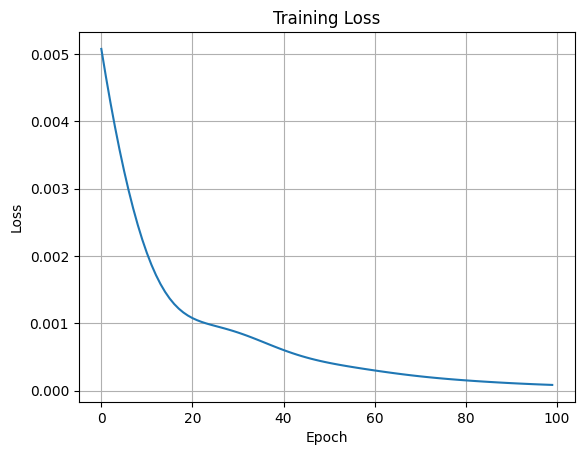

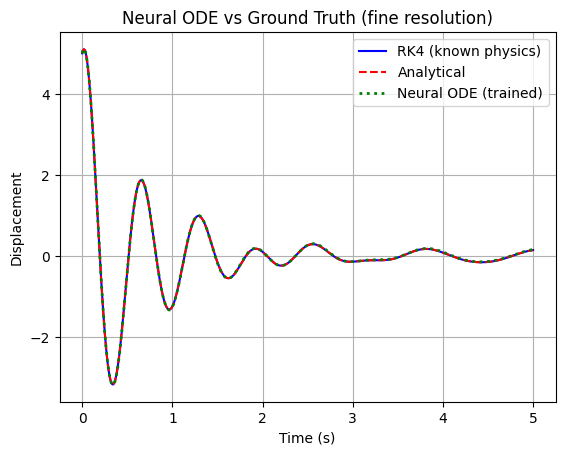

In [5]:

plt.figure()
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.grid(True)
plt.show()

# Validate trained correction_net at fine resolution (dt=0.001)
with torch.no_grad():
    pred_traj_fine = integrate(X0_torch, t_torch, dt)

x_pred_fine = pred_traj_fine[:, 0].numpy()

plt.figure()
plt.plot(t, x_num, 'b-', label='RK4 (known physics)')
plt.plot(t, x_ana, 'r--', label='Analytical')
plt.plot(t, x_pred_fine, 'g:', label='Neural ODE (trained)', linewidth=2)
plt.xlabel('Time (s)')
plt.ylabel('Displacement')
plt.legend()
plt.grid(True)
plt.title('Neural ODE vs Ground Truth (fine resolution)')
plt.show()

In [6]:
with torch.no_grad():
    pred_traj_fine = integrate(X0_torch, t_torch, dt)
x_pred_fine = pred_traj_fine[:, 0].numpy()

neural_error = np.abs(x_pred_fine - x_ana)
print(f"Max error (Neural ODE vs analytical): {np.max(neural_error):.6f}")
print(f"Max error (RK4 known physics vs analytical): {np.max(np.abs(x_num - x_ana)):.2e}")

Max error (Neural ODE vs analytical): 0.017132
Max error (RK4 known physics vs analytical): 1.12e-09


In [7]:
from scipy.integrate import solve_ivp

def f_scipy(t, X):
    x, v = X
    dxdt = v
    dvdt = -wn**2 * x - 2*zeta*wn*v + wn**2 * deltast * np.cos(w*t)
    return [dxdt, dvdt]

sol = solve_ivp(f_scipy, [0, T], [x0, v0], method='RK45', t_eval=t, rtol=1e-8, atol=1e-8)
x_rk45 = sol.y[0]

# Compare the errors
print(f"Max error RK4 vs RK45: {np.max(np.abs(x_num - x_rk45)):.2e}")
print(f"Max error RK45 vs analytical: {np.max(np.abs(x_rk45 - x_ana)):.2e}")

Max error RK4 vs RK45: 2.72e-08
Max error RK45 vs analytical: 2.72e-08


In [8]:
n_runs = 30
noise_std = 3

def f_noisy(t, X, rng, dt_local):
    x, v = X
    noise = rng.normal(0, noise_std) / np.sqrt(dt_local)
    dxdt = v
    dvdt = -wn**2 * x - 2*zeta*wn*v + wn**2 * deltast * np.cos(w*t) + noise
    return np.array([dxdt, dvdt])

In [9]:
final_states_rk4 = []
final_states_rk45 = []

for run in range(n_runs):
    rng = np.random.default_rng(run)

    # Fixed-step RK4 with noise
    X = X0.copy()
    for i in range(len(t)-1):
        X = rk4step(lambda tt, XX: f_noisy(tt, XX, rng, dt), t[i], X, dt)
    final_states_rk4.append(X[0])

    # Adaptive RK45 with noise (scipy doesn't expose internal dt easily per-call,
    # so approximate using a representative dt — see note below)
    rng2 = np.random.default_rng(run)
    sol = solve_ivp(lambda tt, XX: f_noisy(tt, XX, rng2, dt), [0, T], X0, method='RK45', t_eval=[T])
    final_states_rk45.append(sol.y[0, -1])

print(f"RK4 final state: mean={np.mean(final_states_rk4):.3f}, std={np.std(final_states_rk4):.3f}")
print(f"RK45 final state: mean={np.mean(final_states_rk45):.3f}, std={np.std(final_states_rk45):.3f}")

RK4 final state: mean=0.123, std=0.072
RK45 final state: mean=0.156, std=0.038


In [10]:
from scipy import stats
t_stat, p_value = stats.ttest_ind(final_states_rk4, final_states_rk45)
print(f"t-statistic: {t_stat:.3f}, p-value: {p_value:.3f}")

t-statistic: -2.200, p-value: 0.032


In [11]:
#RK4 vs RK45 across multiple noise levels
from joblib import Parallel, delayed

noise_levels = [1e-6, 0.5, 1, 2, 5, 8]
results = []
raw_results = {}   # noise_std -> {'rk4': [...], 'rk45': [...]}

def make_noise_lookup(rng, t_grid, ns_val, dt_val):
    """generate noise at each grid point so both solvers see identical noise."""
    noise_vals = rng.normal(0, ns_val, size=len(t_grid)) / np.sqrt(dt_val)
    def noise_fn(t_query):
        idx = np.searchsorted(t_grid, t_query, side='right') - 1
        idx = np.clip(idx, 0, len(noise_vals) - 1)
        return noise_vals[idx]
    return noise_fn

def f_noisy_fixed(t, X, noise_fn):
    x, v = X
    dxdt = v
    dvdt = -wn**2 * x - 2*zeta*wn*v + wn**2 * deltast * np.cos(w*t) + noise_fn(t)
    return np.array([dxdt, dvdt])

dt_rk4_coarse = 0.05

def single_run(run_idx, ns_val):
    rng = np.random.default_rng(run_idx)
    noise_fn = make_noise_lookup(rng, t, ns_val, dt)

    t_coarse = np.arange(0, T + dt_rk4_coarse, dt_rk4_coarse)
    X_local = X0.copy()
    for i in range(len(t_coarse) - 1):
        X_local = rk4step(lambda tt, XX: f_noisy_fixed(tt, XX, noise_fn), t_coarse[i], X_local, dt_rk4_coarse)

    sol = solve_ivp(lambda tt, XX: f_noisy_fixed(tt, XX, noise_fn), [0, T], X0,
                     method='RK45', t_eval=[T], rtol=1e-6, atol=1e-6)
    return X_local[0], sol.y[0, -1]

for ns in noise_levels:
    print(f'\nNoise std = {ns}')
    run_results = Parallel(n_jobs=-1)(
        delayed(single_run)(run, ns) for run in range(30)
    )
    final_rk4  = [r[0] for r in run_results]
    final_rk45 = [r[1] for r in run_results]

    #raw values for histograms later
    raw_results[ns] = {'rk4': final_rk4, 'rk45': final_rk45}

    t_stat, p_value = stats.ttest_ind(final_rk4, final_rk45)
    std_ratio = np.std(final_rk4) / np.std(final_rk45)
    results.append({
        'noise_std': ns,
        'rk4_mean':  np.mean(final_rk4),
        'rk4_std':   np.std(final_rk4),
        'rk45_mean': np.mean(final_rk45),
        'rk45_std':  np.std(final_rk45),
        'std_ratio': std_ratio,
        'p_value':   p_value
    })
    print(f'  RK4:  mean={np.mean(final_rk4):.4f}, std={np.std(final_rk4):.4f}')
    print(f'  RK45: mean={np.mean(final_rk45):.4f}, std={np.std(final_rk45):.4f}')
    print(f'  std_ratio={std_ratio:.3f}, p={p_value:.4f}')

import pandas as pd
df = pd.DataFrame(results)
print('\nSummary:')
df



Noise std = 1e-06
  RK4:  mean=0.1515, std=0.0000
  RK45: mean=0.1516, std=0.0000
  std_ratio=1.079, p=0.0000

Noise std = 0.5
  RK4:  mean=0.1334, std=0.1279
  RK45: mean=0.1570, std=0.0220
  std_ratio=5.801, p=0.3311

Noise std = 1
  RK4:  mean=0.1152, std=0.2558
  RK45: mean=0.1628, std=0.0438
  std_ratio=5.847, p=0.3279

Noise std = 2
  RK4:  mean=0.0790, std=0.5116
  RK45: mean=0.1740, std=0.0881
  std_ratio=5.805, p=0.3285

Noise std = 5
  RK4:  mean=-0.0299, std=1.2790
  RK45: mean=0.2067, std=0.2187
  std_ratio=5.848, p=0.3302

Noise std = 8
  RK4:  mean=-0.1387, std=2.0464
  RK45: mean=0.2390, std=0.3499
  std_ratio=5.848, p=0.3312

Summary:


,noise_std,rk4_mean,rk4_std,rk45_mean,rk45_std,std_ratio,p_value
0,0.000001,0.151528,2.558047e-07,0.151588,2.371159e-07,1.078817,1.595049e-122
1,0.500000,0.133386,1.279024e-01,0.157009,2.204658e-02,5.801462,3.310885e-01
2,1.000000,0.115244,2.558047e-01,0.162795,4.375246e-02,5.846637,3.278858e-01
3,2.000000,0.078960,5.116095e-01,0.173955,8.813571e-02,5.804792,3.285230e-01
4,5.000000,-0.029892,1.279024e+00,0.206704,2.187158e-01,5.847879,3.302250e-01
5,8.000000,-0.138744,2.046438e+00,0.239021,3.499360e-01,5.848034,3.312254e-01


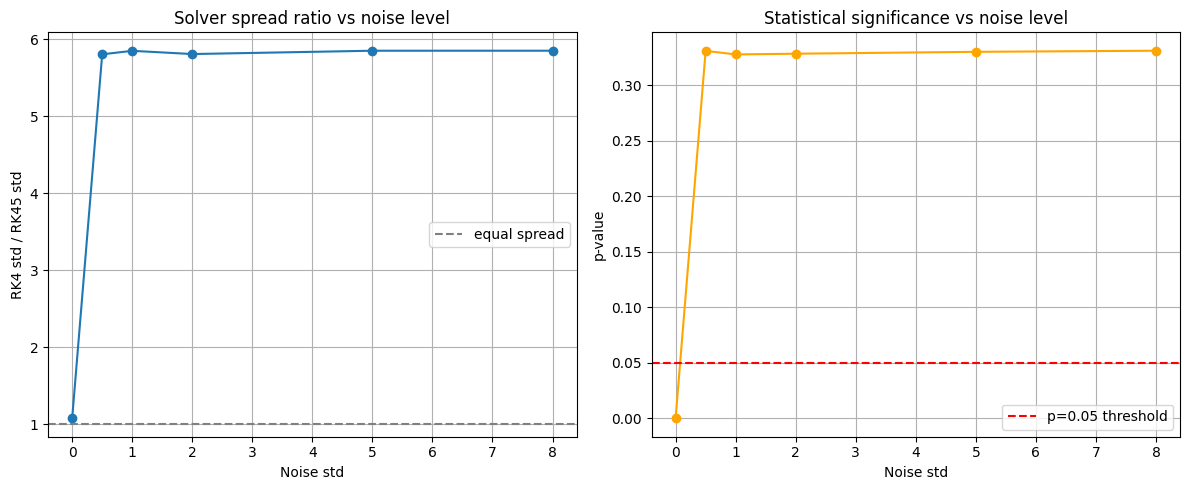

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(df['noise_std'], df['std_ratio'], 'o-')
axes[0].axhline(1, color='gray', linestyle='--', label='equal spread')
axes[0].set_xlabel('Noise std')
axes[0].set_ylabel('RK4 std / RK45 std')
axes[0].set_title('Solver spread ratio vs noise level')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(df['noise_std'], df['p_value'], 'o-', color='orange')
axes[1].axhline(0.05, color='red', linestyle='--', label='p=0.05 threshold')
axes[1].set_xlabel('Noise std')
axes[1].set_ylabel('p-value')
axes[1].set_title('Statistical significance vs noise level')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

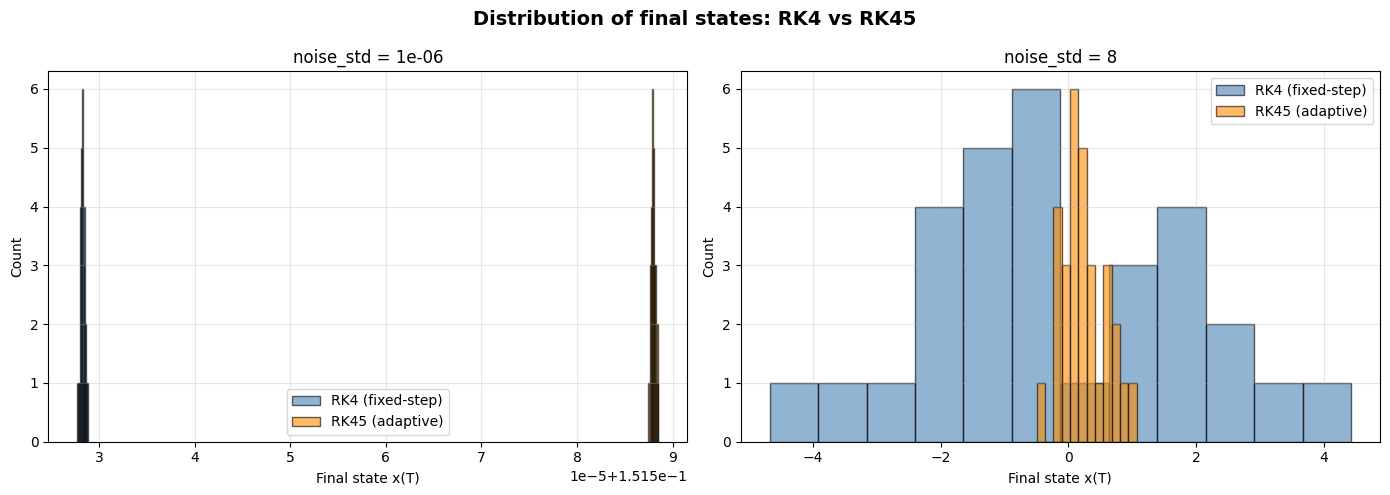

In [13]:
#Histograms: distribution of final states at low vs high noise
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

low_noise  = noise_levels[0]
high_noise = noise_levels[-1]

for ax, ns in zip(axes, [low_noise, high_noise]):
    rk4_vals  = raw_results[ns]['rk4']
    rk45_vals = raw_results[ns]['rk45']
    ax.hist(rk4_vals,  bins=12, alpha=0.6, label='RK4 (fixed-step)',
            color='steelblue', edgecolor='black')
    ax.hist(rk45_vals, bins=12, alpha=0.6, label='RK45 (adaptive)',
            color='darkorange', edgecolor='black')
    ax.set_xlabel('Final state x(T)')
    ax.set_ylabel('Count')
    ax.set_title(f'noise_std = {ns}')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Distribution of final states: RK4 vs RK45',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
